# pyFDN parameter-spec FLAMO graphs

Every registered pyFDN parameter specification is sampled, converted into its complete `BasicFDN`, compiled through `pyFDN.dss_to_flamo` via `to_flamo`, and drawn with `pyFDN.plot_flamo_graph`. The executed image outputs are committed so GitHub renders the verified graph inventory.

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from IPython.display import Markdown, display
from pyFDN import plot_flamo_graph

from synth_setter.data.pyfdn_param_spec import (
    BasicFDNParamSpec,
    pyfdn_param_spec_sha256,
)
from synth_setter.data.vst.param_spec_registry import param_specs

In [ ]:
pyfdn_specs = {
    name: spec for name, spec in sorted(param_specs.items()) if name.startswith("pyfdn_")
}
assert pyfdn_specs
assert all(isinstance(spec, BasicFDNParamSpec) for spec in pyfdn_specs.values())
tuple(pyfdn_specs)

('pyfdn_n8_mono_householder',
 'pyfdn_n8_mono_householder_vector',
 'pyfdn_n8_mono_kronecker')

## `pyfdn_n8_mono_householder`

param-spec SHA-256: 409ed01ba270efcbd5a3dca6d8404f8824aada9b66fae8057210de902899210a


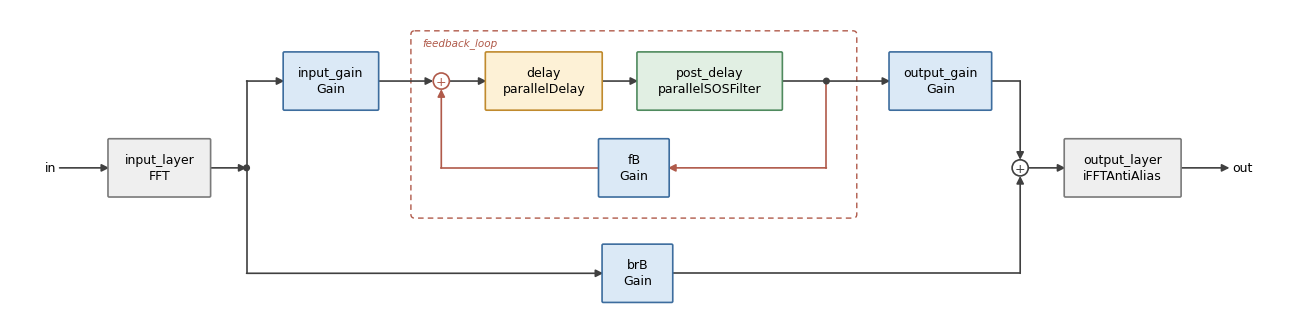

## `pyfdn_n8_mono_householder_vector`

param-spec SHA-256: b9a5086d63da5ef9817d4c57251ed7e61c575fcfaa68c73d146db42d9db5edbb


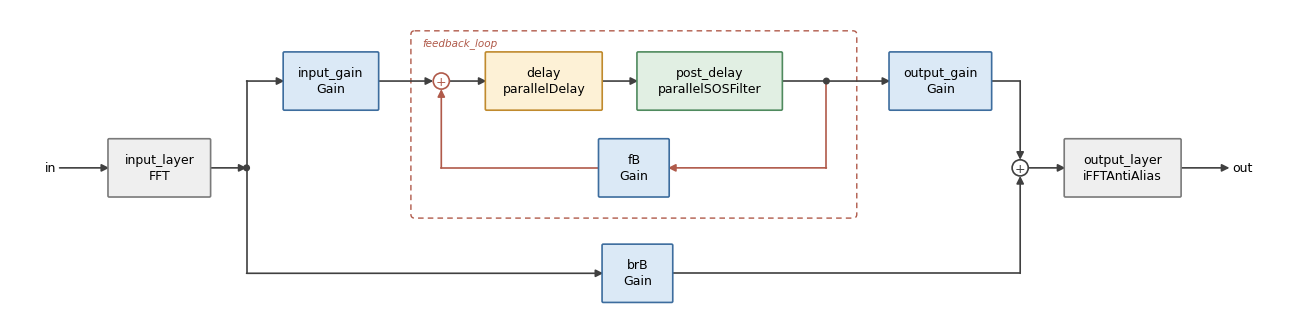

## `pyfdn_n8_mono_kronecker`

param-spec SHA-256: a2e761fcad8eb80e4e89d4ac553769726e827603bc32cc7ebea594c33d1bc6f6


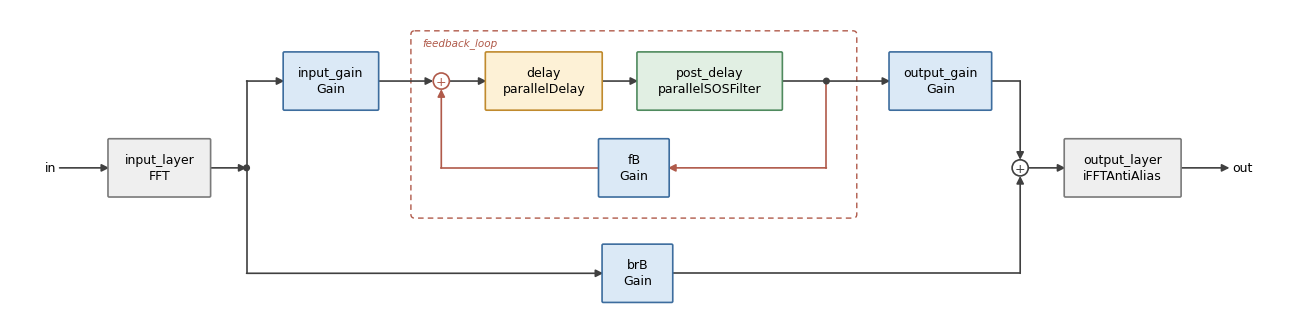

In [ ]:
for index, (name, spec) in enumerate(pyfdn_specs.items()):
    native, _ = spec.sample(np.random.default_rng(index))
    model = spec.to_basic_fdn(native).to_flamo(nfft=4096)
    display(Markdown(f"## `{name}`"))
    print(f"param-spec SHA-256: {pyfdn_param_spec_sha256(spec)}")
    plot_flamo_graph(model, name=name)
    plt.show()